<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Atmosphere Diagnostic 2 - Propagation and Flux
---

This notebook diagnoses the propagation layer of the atmosphere package: `tpeanuts.medium.atmosphere.evolutor`, `probability`, and `flux`, plus the atmosphere-plus-Earth composition used by `pipeline.atmosphere` and `pipeline.atmosphere_earth`. The corresponding pytest files are `test5_evolutor`, `test6_probability`, `test7_flux`, and `test8_legacy`; here we keep visual checks and physical interpretation.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Evolution-Operator) | **Evolution Operator** |
| [4](#4.-Atmosphere-Probabilities) | **Atmosphere Probabilities** |
| [5](#5.-Atmosphere-Flux) | **Atmosphere Flux** |
| [6](#6.-Atmosphere-plus-Earth-Legacy-Limit) | **Atmosphere-plus-Earth Legacy Limit** |
| [7](#7.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Coherent Evolution Through the Atmosphere

For a neutrino produced at altitude $h$ and arriving at a detector zenith angle $\theta$, the atmosphere module propagates the flavour state from the production point to the Earth surface. In the flavour basis, the coherent evolution is

$$
\psi_{\rm surf}(E,h,\theta)=S_{\rm atm}(E,h,\theta)\,\psi_{\rm prod},
$$

where $S_{\rm atm}$ is built from path-ordered products of segment evolution matrices. For a segment with dimensionless width $\Delta x$,

$$
S_k = \exp[-i H_k(E,n_e)\Delta x],
\qquad
S_{\rm atm}=S_N\cdots S_2 S_1.
$$

The Hamiltonian contains the vacuum kinetic term and, when enabled, the charged-current matter term proportional to the electron density $n_e$. This is the standard MSW matter term used in neutrino oscillation theory.

### 0.2 Unitarity and Probability Conservation

For a Hermitian Hamiltonian, the evolution operator must be unitary,

$$
S^\dagger S = I.
$$

The transition probability convention used by the package is

$$
P_{\beta\alpha}=|S_{\beta\alpha}|^2,
$$

where $\alpha$ is the initial flavour and $\beta$ is the final flavour. Probability conservation therefore requires

$$
\sum_\beta P_{\beta\alpha}=1
$$

for every initial flavour column.

### 0.3 Coherent and Incoherent Initial States

`atmosphere_probability_state` supports two physical interpretations of the initial state. With `massbasis=False`, the input is a coherent flavour-amplitude vector and the result is

$$
P_\beta = |(S_{\rm atm}\psi)_\beta|^2.
$$

With `massbasis=True`, the input is an incoherent vector of mass-basis weights $w_i$ and the final flavour distribution is

$$
P_\beta = \sum_i |(S_{\rm atm}U)_{\beta i}|^2 w_i.
$$

This distinction matters because atmospheric production is naturally flavour-tagged, while solar-neutrino Earth regeneration is often treated as an incoherent mass mixture.

### 0.4 Flux Propagation

The atmosphere flux helper applies a flux normalization and optional spectral factor to final flavour probabilities,

$$
\Phi_\beta(E,h,\theta)=P_\beta(E,h,\theta)\,\Phi_0(E,h,\theta)\,f(E).
$$

For a normalized initial state and unitary propagation, the flavour sum is conserved up to the supplied normalization.

### 0.5 Atmosphere-plus-Earth Composition and Legacy Limit

The full detector pipeline composes atmosphere propagation with Earth propagation,

$$
S_{\rm det}=S_\oplus S_{\rm atm}.
$$

When $h=0$, the atmosphere path length is zero and $S_{\rm atm}=I$. In that limit, the atmosphere-plus-Earth pipeline must reduce to the Earth propagation reference used by legacy `peanuts`.

### References

- L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D 17, 2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, *Resonant amplification of neutrino oscillations in matter*, Nuovo Cim. C 9, 17 (1986).
- Particle Data Group, *Review of Particle Physics*, neutrino mixing and oscillations review.
- NuFIT 5.2, I. Esteban et al., global oscillation fit tables, http://www.nu-fit.org.

## 1. Libraries

All imports are centralized here. The notebook uses package APIs and the shared notebook plotting helper.

In [1]:
from __future__ import annotations

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.probability import probability_incoherent, probability_transition
from tpeanuts.medium.atmosphere.evolutor import atmosphere_evolutor
from tpeanuts.medium.atmosphere.flux import atmosphere_flux_state
from tpeanuts.medium.atmosphere.geometry import theta_to_eta
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition, atmosphere_probability_state
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters
from tpeanuts.pipeline.atmosphere import propagate_atmosphere_to_surface
from tpeanuts.pipeline.atmosphere_earth import propagate_surface_to_detector
from tpeanuts.util.context import RuntimeContext
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import FLAVOUR_LABELS, save_and_show, to_numpy

## 2. Paths and Configuration

### 2.1 Paths

The output directory follows the notebook relative location below `notebooks/`: diagnostic figures from this notebook are saved under `diagnostic/atmosphere`.

In [2]:
config = load_notebook_config()
OUTPUT_DIR = config.output_dir("diagnostic", "atmosphere")
SHOW_PLOTS = config.show_plots

print(f"Repository root: {config.package_dir}")
print(f"Figure output directory: {OUTPUT_DIR}")

Repository root: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Figure output directory: v:\output\diagnostic\atmosphere


### 2.2 Configuration

The diagnostics use the NUFIT 5.2 normal-ordering preset, a representative atmosphere production height of 20 km, and a detector depth of 1 km. The default propagation settings use a vacuum atmosphere to isolate numerical propagation; dedicated cells enable atmospheric matter to quantify the size of the matter correction.

**Expected results**: evolution matrices should be unitary, probability columns should sum to one, flux sums should track the supplied normalization, and the atmospheric matter correction should be small compared with vacuum oscillations for typical atmospheric densities.

In [3]:
ctx = RuntimeContext.resolve(config.device, config.dtype)
DEVICE = ctx.device
DTYPE = ctx.dtype
CDTYPE = torch.complex128 if DTYPE == torch.float64 else torch.complex64

oscillation = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", context=ctx)
atm_vac = AtmosphereParameters(
    atmosphere_density_source="exponential",
    nsteps=96,
    method="midpoint",
    matter=False,
)
atm_mat = AtmosphereParameters(
    atmosphere_density_source="exponential",
    nsteps=96,
    method="midpoint",
    matter=True,
)

E0_MEV = torch.tensor(1000.0, device=DEVICE, dtype=DTYPE)
H0_KM = torch.tensor(20.0, device=DEVICE, dtype=DTYPE)
THETA0_DEG = torch.tensor(45.0, device=DEVICE, dtype=DTYPE)
DEPTH_KM = torch.tensor(1.0, device=DEVICE, dtype=DTYPE)

state_e = torch.tensor([1.0, 0.0, 0.0], device=DEVICE, dtype=CDTYPE)
state_mu = torch.tensor([0.0, 1.0, 0.0], device=DEVICE, dtype=CDTYPE)
state_tau = torch.tensor([0.0, 0.0, 1.0], device=DEVICE, dtype=CDTYPE)

print("device:", DEVICE)
print("dtype:", DTYPE)
print("oscillation preset:", oscillation.preset_name)

device: cpu
dtype: torch.float64
oscillation preset: _SM_NUFIT52_NO


### 2.3 Local Helpers

Small helpers keep plotting cells focused on the diagnostic quantity being shown.

In [4]:
def unitarity_error(S: torch.Tensor) -> torch.Tensor:
    eye = torch.eye(S.shape[-1], device=S.device, dtype=S.dtype)
    return torch.linalg.norm(S.conj().transpose(-2, -1) @ S - eye.expand_as(S), dim=(-2, -1))


def probability_column_error(P: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.abs(P.sum(dim=-2) - 1.0))


def flavour_dataframe(values: torch.Tensor, x: torch.Tensor, x_name: str) -> pd.DataFrame:
    arr = to_numpy(values)
    return pd.DataFrame({
        x_name: to_numpy(x),
        "nu_e": arr[..., 0],
        "nu_mu": arr[..., 1],
        "nu_tau": arr[..., 2],
    })

## 3. Evolution Operator

### 3.1 Unitarity and Step Convergence

This diagnostic scans the number of atmosphere segments and measures $\|S^\dagger S-I\|$. Because each segment is generated from a Hermitian Hamiltonian, the error should remain close to floating-point precision.

**Expected results**: all unitarity errors should be very small and should not grow pathologically with the number of segments.

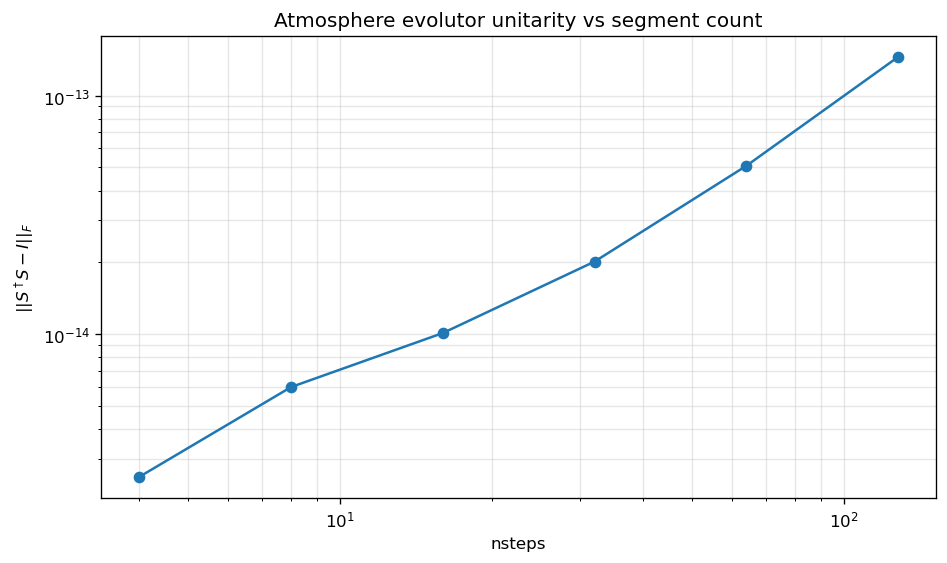

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig3_1_unitarity_vs_nsteps.png


,nsteps,unitarity_error
0,4,2.529601e-15
1,8,6.011509e-15
2,16,1.011952e-14
3,32,2.015622e-14
4,64,5.074749e-14
5,128,1.449782e-13


In [5]:
steps = torch.tensor([4, 8, 16, 32, 64, 128], device=DEVICE)
errors = []
for nsteps in steps.tolist():
    atm = AtmosphereParameters(atmosphere_density_source="exponential", nsteps=int(nsteps), method="midpoint", matter=False)
    S, _ = atmosphere_evolutor(
        oscillation,
        E_MeV=E0_MEV,
        h_km=H0_KM,
        theta_deg=THETA0_DEG,
        depth_km=DEPTH_KM,
        atmosphere=atm,
        context=ctx,
    )
    errors.append(float(unitarity_error(S).detach().cpu()))

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.loglog(to_numpy(steps), np.maximum(errors, 1e-18), marker="o")
ax.set_xlabel("nsteps")
ax.set_ylabel(r"$||S^\dagger S-I||_F$")
ax.set_title("Atmosphere evolutor unitarity vs segment count")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig3_1_unitarity_vs_nsteps.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

pd.DataFrame({"nsteps": to_numpy(steps), "unitarity_error": errors})

### 3.2 Vacuum and Matter Operators

This comparison visualizes how small the atmospheric matter correction is for a long near-horizontal path. The atmosphere matter density is much lower than Earth or solar densities, so the difference between vacuum and matter propagation should be modest.

**Expected results**: both operators should be unitary; the matrix-element difference should be finite and small.

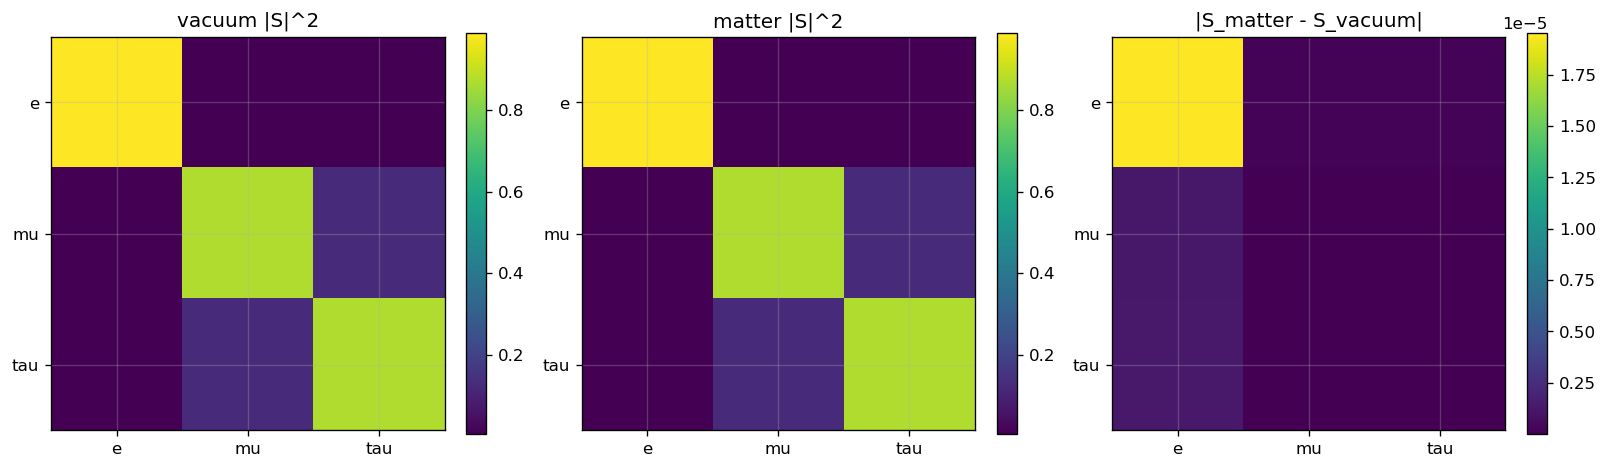

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig3_2_vacuum_matter_operator.png


,metric,value
0,unitarity_vacuum,6.174413e-14
1,unitarity_matter,3.313966e-14
2,operator_delta_norm,1.961104e-05


In [6]:
S_vac, _ = atmosphere_evolutor(
    oscillation,
    E_MeV=5000.0,
    h_km=80.0,
    theta_deg=85.0,
    depth_km=DEPTH_KM,
    atmosphere=atm_vac,
    context=ctx,
)
S_mat, _ = atmosphere_evolutor(
    oscillation,
    E_MeV=5000.0,
    h_km=80.0,
    theta_deg=85.0,
    depth_km=DEPTH_KM,
    atmosphere=atm_mat,
    context=ctx,
)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
for ax, matrix, title in [
    (axes[0], torch.abs(S_vac) ** 2, "vacuum |S|^2"),
    (axes[1], torch.abs(S_mat) ** 2, "matter |S|^2"),
    (axes[2], torch.abs(S_mat - S_vac), "|S_matter - S_vacuum|"),
]:
    im = ax.imshow(to_numpy(matrix), origin="upper", cmap="viridis")
    ax.set_title(title)
    ax.set_xticks(range(3), ["e", "mu", "tau"])
    ax.set_yticks(range(3), ["e", "mu", "tau"])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig3_2_vacuum_matter_operator.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

pd.DataFrame({
    "metric": ["unitarity_vacuum", "unitarity_matter", "operator_delta_norm"],
    "value": [float(unitarity_error(S_vac)), float(unitarity_error(S_mat)), float(torch.linalg.norm(S_mat - S_vac))],
})

## 4. Atmosphere Probabilities

### 4.1 Probability Matrix Diagnostics

The full transition matrix is $P_{\beta\alpha}=|S_{\beta\alpha}|^2$. The columns must sum to one because each column corresponds to a fixed initial flavour.

**Expected results**: every probability is between zero and one and every column sum is one within numerical precision.

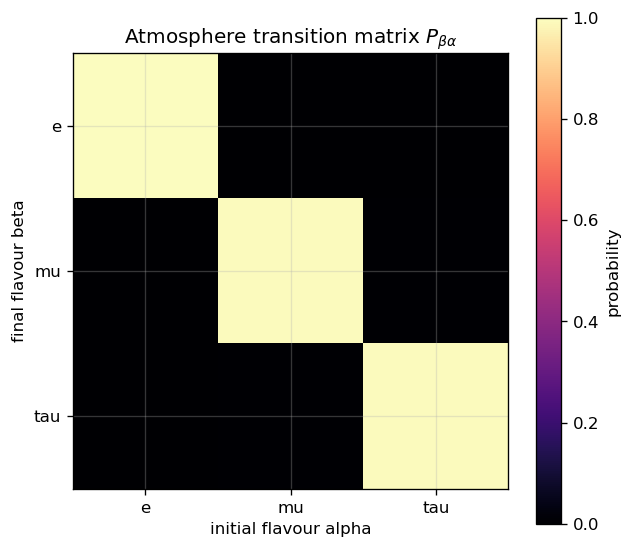

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig4_1_probability_matrix.png


,e,mu,tau
e,0.999306,0.000336,0.000357
mu,0.000333,0.992440,0.007227
tau,0.000361,0.007224,0.992416


max column normalization error: 4.1522341120980855e-14


In [7]:
P0 = atmosphere_probability_transition(
    oscillation,
    E_MeV=E0_MEV,
    h_km=H0_KM,
    theta_deg=THETA0_DEG,
    depth_km=DEPTH_KM,
    atmosphere=atm_vac,
    context=ctx,
)

fig, ax = plt.subplots(figsize=(5.4, 4.8))
im = ax.imshow(to_numpy(P0), vmin=0.0, vmax=1.0, cmap="magma")
ax.set_title(r"Atmosphere transition matrix $P_{\beta\alpha}$")
ax.set_xlabel("initial flavour alpha")
ax.set_ylabel("final flavour beta")
ax.set_xticks(range(3), ["e", "mu", "tau"])
ax.set_yticks(range(3), ["e", "mu", "tau"])
fig.colorbar(im, ax=ax, label="probability")
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig4_1_probability_matrix.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(pd.DataFrame(to_numpy(P0), index=["e", "mu", "tau"], columns=["e", "mu", "tau"]))
print("max column normalization error:", float(probability_column_error(P0)))

### 4.2 Probability Versus Production Height and Zenith Angle

The path length through the atmosphere depends on both production height and detector zenith angle. Oscillation phases therefore vary with both variables.

**Expected results**: probabilities remain normalized, and variations become stronger when the path length grows toward large zenith angles.

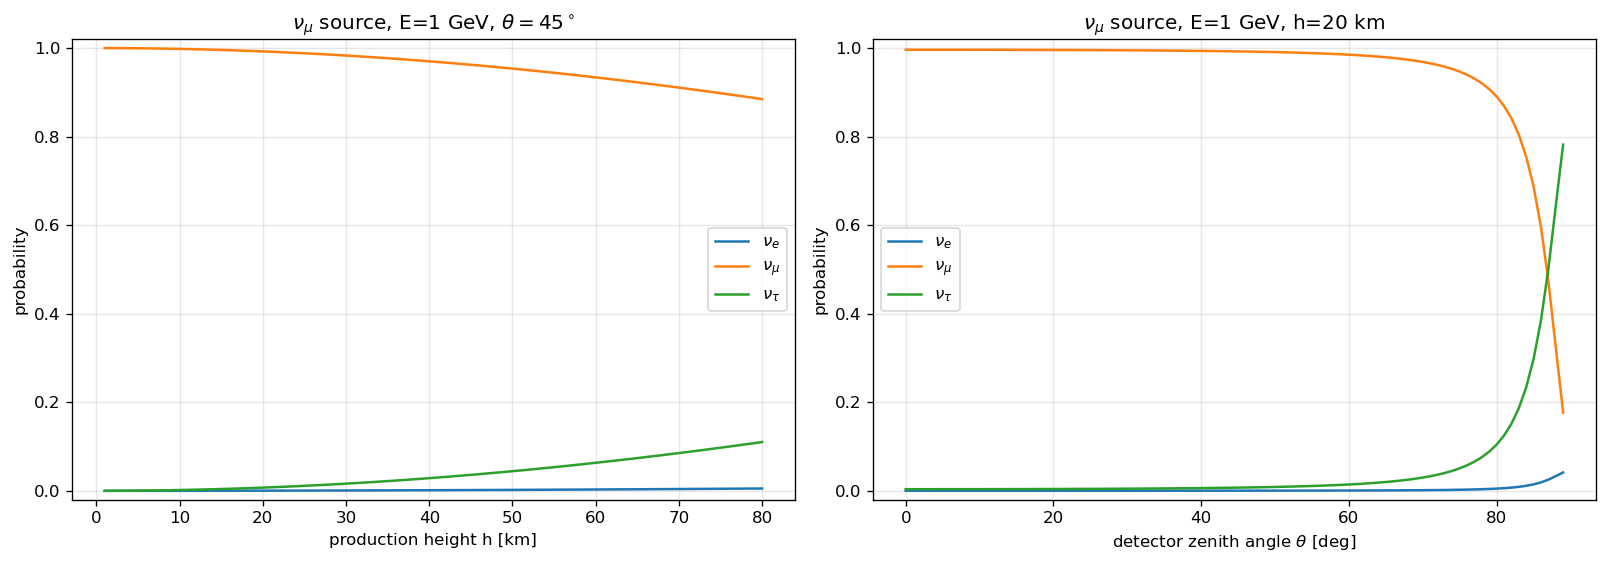

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig4_2_probability_height_theta.png


,scan,max_norm_error
0,height,7.405188e-14
1,theta,8.282264e-14


In [8]:
h_grid = torch.linspace(1.0, 80.0, 80, device=DEVICE, dtype=DTYPE)
theta_grid = torch.linspace(0.0, 89.0, 90, device=DEVICE, dtype=DTYPE)

P_vs_h = atmosphere_probability_state(
    state_mu,
    oscillation,
    E_MeV=E0_MEV,
    h_km=h_grid,
    theta_deg=45.0,
    depth_km=DEPTH_KM,
    atmosphere=atm_vac,
    context=ctx,
)
P_vs_theta = atmosphere_probability_state(
    state_mu,
    oscillation,
    E_MeV=E0_MEV,
    h_km=H0_KM,
    theta_deg=theta_grid,
    depth_km=DEPTH_KM,
    atmosphere=atm_vac,
    context=ctx,
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(to_numpy(h_grid), to_numpy(P_vs_h[:, i]), label=label)
    axes[1].plot(to_numpy(theta_grid), to_numpy(P_vs_theta[:, i]), label=label)
axes[0].set_xlabel("production height h [km]")
axes[0].set_ylabel("probability")
axes[0].set_title(r"$\nu_\mu$ source, E=1 GeV, $\theta=45^\circ$")
axes[1].set_xlabel(r"detector zenith angle $\theta$ [deg]")
axes[1].set_ylabel("probability")
axes[1].set_title(r"$\nu_\mu$ source, E=1 GeV, h=20 km")
for ax in axes:
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig4_2_probability_height_theta.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

pd.DataFrame({
    "scan": ["height", "theta"],
    "max_norm_error": [
        float(torch.max(torch.abs(P_vs_h.sum(dim=-1) - 1.0))),
        float(torch.max(torch.abs(P_vs_theta.sum(dim=-1) - 1.0))),
    ],
})

### 4.3 Muon Survival Probability Versus Energy

Atmospheric oscillations are controlled mainly by the ratio $L/E$. A multi-angle energy scan shows the expected shift of oscillation features with path length.

**Expected results**: near-horizontal trajectories show stronger phase development than vertical short paths at the same energy.

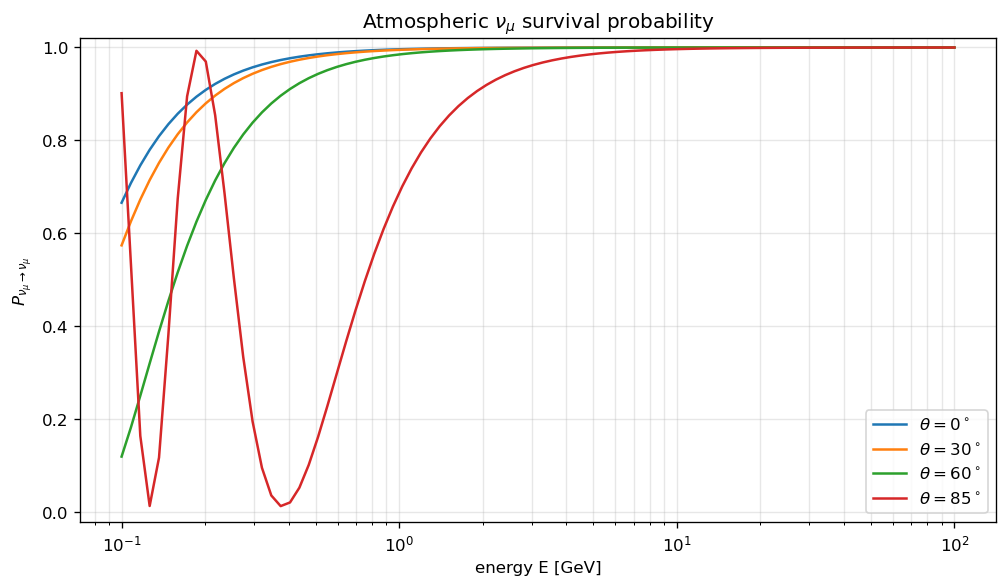

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig4_3_mumu_survival_energy.png


In [9]:
E_grid_GeV = torch.logspace(-1.0, 2.0, 90, device=DEVICE, dtype=DTYPE)
theta_values = [0.0, 30.0, 60.0, 85.0]
P_mumu = {}
for theta_value in theta_values:
    p = atmosphere_probability_state(
        state_mu,
        oscillation,
        E_MeV=(E_grid_GeV * 1.0e3)[:, None],
        h_km=H0_KM,
        theta_deg=theta_value,
        depth_km=DEPTH_KM,
        atmosphere=atm_vac,
        context=ctx,
    )
    P_mumu[theta_value] = p[:, 1] if p.ndim == 2 else p[:, 0, 1]

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for theta_value, values in P_mumu.items():
    ax.semilogx(to_numpy(E_grid_GeV), to_numpy(values), label=rf"$\theta={theta_value:.0f}^\circ$")
ax.set_xlabel("energy E [GeV]")
ax.set_ylabel(r"$P_{\nu_\mu\to\nu_\mu}$")
ax.set_title(r"Atmospheric $\nu_\mu$ survival probability")
ax.set_ylim(-0.02, 1.02)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig4_3_mumu_survival_energy.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Atmosphere Flux

### 5.1 Synthetic Flux Propagation

This section uses an arbitrary but positive source flux to verify that `atmosphere_flux_state` applies probabilities, flux normalization, and spectrum consistently.

**Expected results**: the sum over final flavours equals the input normalization times the spectral factor because the initial state is normalized and propagation is unitary.

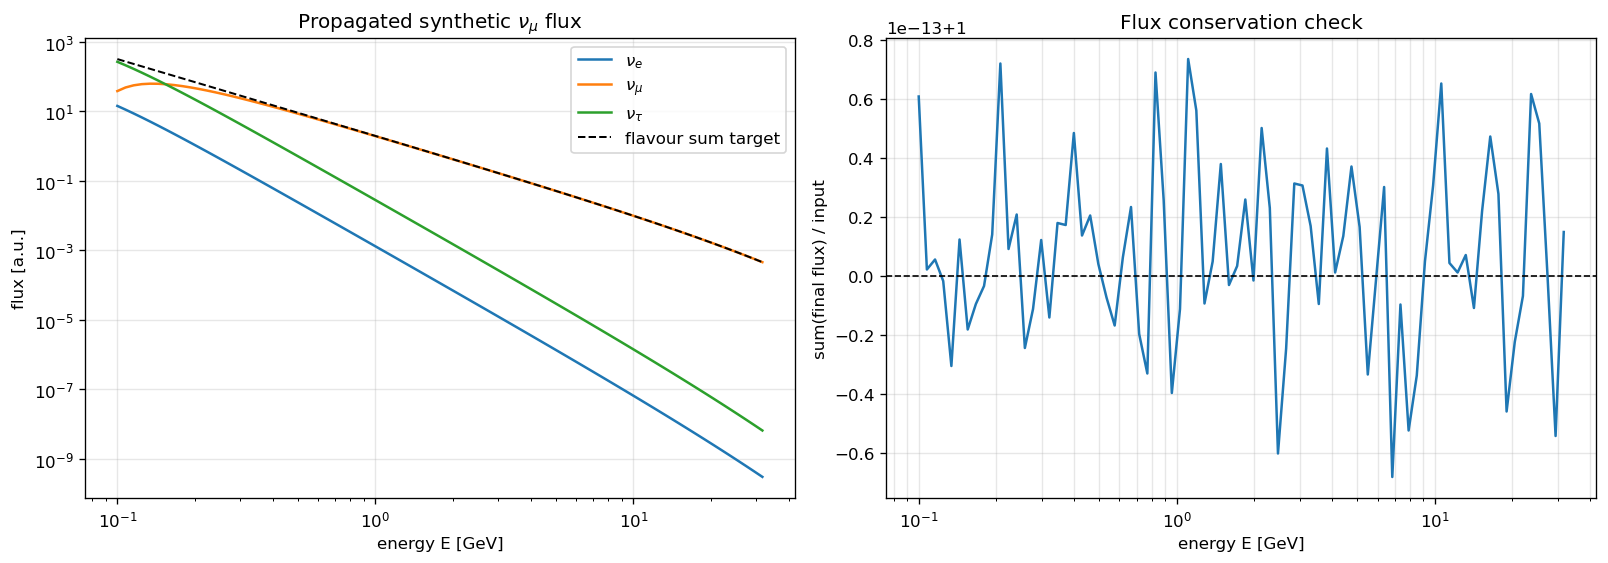

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig5_1_synthetic_flux.png
max flux-sum residual: 1.9269918993813917e-11


In [10]:
E_flux_GeV = torch.logspace(-1.0, 1.5, 80, device=DEVICE, dtype=DTYPE)
flux_norm = 2.0 * E_flux_GeV.pow(-2.2)
spectrum = torch.exp(-E_flux_GeV / 40.0)

flux_mu = atmosphere_flux_state(
    state_mu,
    oscillation,
    E_MeV=(E_flux_GeV * 1.0e3)[:, None],
    h_km=H0_KM,
    theta_deg=60.0,
    flux=flux_norm,
    spectrum=spectrum,
    depth_km=DEPTH_KM,
    atmosphere=atm_vac,
    context=ctx,
)
expected_total = flux_norm * spectrum

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].loglog(to_numpy(E_flux_GeV), to_numpy(flux_mu[:, i]), label=label)
axes[0].loglog(to_numpy(E_flux_GeV), to_numpy(expected_total), "k--", lw=1.2, label="flavour sum target")
axes[0].set_xlabel("energy E [GeV]")
axes[0].set_ylabel("flux [a.u.]")
axes[0].set_title(r"Propagated synthetic $\nu_\mu$ flux")
axes[0].legend()
ratio = flux_mu.sum(dim=-1) / expected_total
axes[1].semilogx(to_numpy(E_flux_GeV), to_numpy(ratio))
axes[1].axhline(1.0, color="k", ls="--", lw=1.0)
axes[1].set_xlabel("energy E [GeV]")
axes[1].set_ylabel("sum(final flux) / input")
axes[1].set_title("Flux conservation check")
axes[1].grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig5_1_synthetic_flux.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("max flux-sum residual:", float(torch.max(torch.abs(flux_mu.sum(dim=-1) - expected_total))))

### 5.2 Height-Integrated Flux Sketch

A simple height-dependent flux grid illustrates the same operation used in atmosphere production tables: probabilities are evaluated for each height and the result can be integrated over production height.

**Expected results**: the height-integrated total flux is conserved relative to the synthetic source normalization.

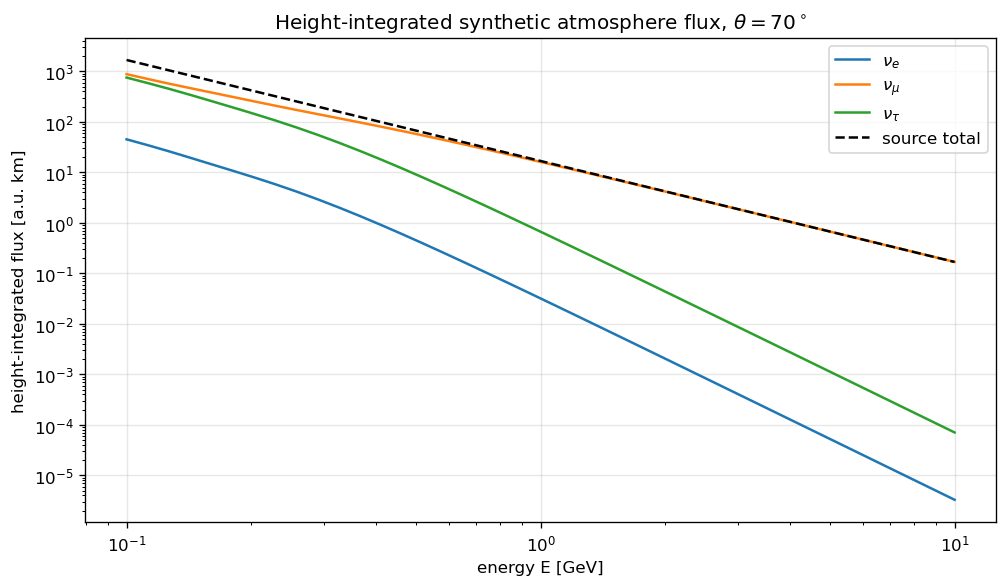

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig5_2_height_integrated_flux.png
max integrated total residual: 8.640199666842818e-12


In [11]:
h_flux_grid = torch.linspace(1.0, 80.0, 50, device=DEVICE, dtype=DTYPE)
E_grid = torch.logspace(-1.0, 1.0, 40, device=DEVICE, dtype=DTYPE)
EE, HH = torch.meshgrid(E_grid, h_flux_grid, indexing="ij")
source_norm = torch.exp(-HH / 18.0) * EE.pow(-2.0)

# Broadcast one energy-height grid through atmosphere_probability_state by giving both E and h a 2-D shape.
P_grid = atmosphere_probability_state(
    state_mu,
    oscillation,
    E_MeV=EE * 1.0e3,
    h_km=HH,
    theta_deg=70.0,
    depth_km=DEPTH_KM,
    atmosphere=AtmosphereParameters(atmosphere_density_source="exponential", nsteps=48, method="midpoint", matter=False),
    context=ctx,
)
flux_grid = P_grid * source_norm[..., None]
source_integrated = torch.trapezoid(source_norm, h_flux_grid, dim=1)
det_integrated = torch.trapezoid(flux_grid, h_flux_grid, dim=1)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for i, label in enumerate(FLAVOUR_LABELS):
    ax.loglog(to_numpy(E_grid), to_numpy(det_integrated[:, i]), label=label)
ax.loglog(to_numpy(E_grid), to_numpy(source_integrated), "k--", label="source total")
ax.set_xlabel("energy E [GeV]")
ax.set_ylabel("height-integrated flux [a.u. km]")
ax.set_title(r"Height-integrated synthetic atmosphere flux, $\theta=70^\circ$")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig5_2_height_integrated_flux.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("max integrated total residual:", float(torch.max(torch.abs(det_integrated.sum(dim=-1) - source_integrated))))

## 6. Atmosphere-plus-Earth Legacy Limit

### 6.1 Zero-Height Pipeline Limit

When the production altitude is zero, the atmosphere segment has zero length. The full pipeline probability matrix should therefore be the Earth-only matrix. This is the limit used in `test8_legacy` to compare against legacy `peanuts` without introducing a separate legacy atmosphere implementation.

**Expected results**: $S_{\rm atm}=I$, the combined probability matrix is normalized, and detector flux propagation is just the matrix action on the input flux vector.

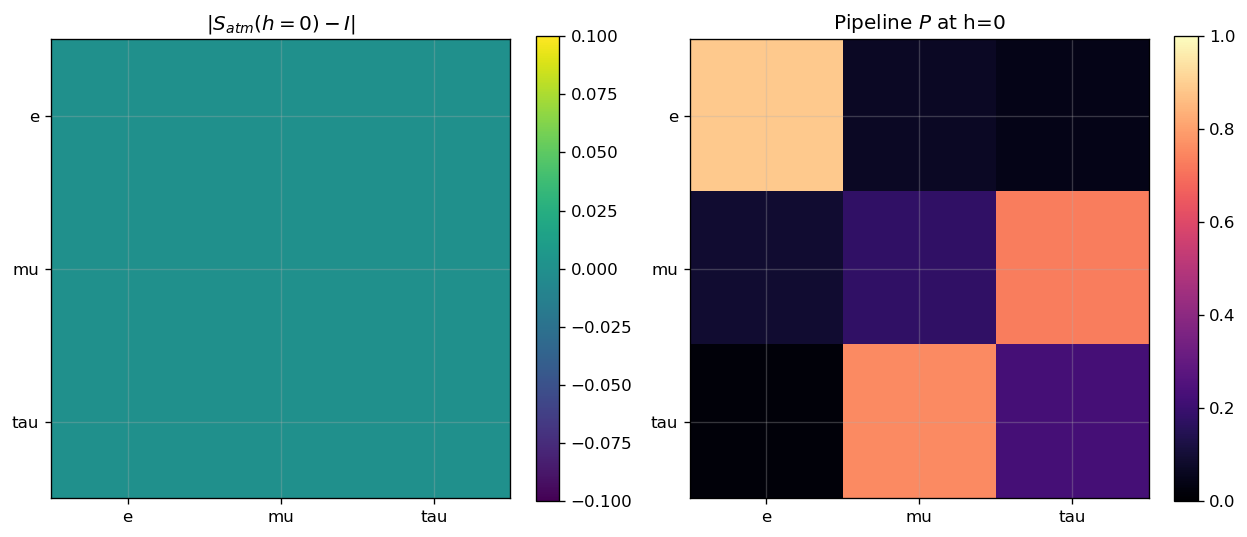

v:\output\diagnostic\atmosphere\diagnostic2_atmosphere_fig6_1_zero_height_legacy_limit.png


,metric,value
0,eta_rad,1.047198e+00
1,max_abs_Satm_minus_I,0.000000e+00
2,probability_column_error,4.440892e-16
3,flux_sum_input,3.500000e+00
4,flux_sum_output,3.500000e+00


flux_out: tensor([1.045143e+00, 8.133236e-01, 1.641533e+00], dtype=torch.float64)


In [12]:
theta_earth_deg = torch.tensor(120.0, device=DEVICE, dtype=DTYPE)
eta_earth = theta_to_eta(theta_earth_deg, device=DEVICE, dtype=DTYPE)
S_zero, x_zero = atmosphere_evolutor(
    oscillation,
    E_MeV=E0_MEV,
    h_km=0.0,
    theta_deg=theta_earth_deg,
    depth_km=0.0,
    atmosphere=AtmosphereParameters(atmosphere_density_source="exponential", nsteps=16, method="midpoint", matter=False),
    context=ctx,
)
pipeline_config = PropagationConfig(
    runtime=ctx, oscillation=oscillation,
    atmosphere=AtmosphereParameters(atmosphere_density_source="exponential", nsteps=16, method="midpoint", matter=False),
    reunitarize_earth=True,
)
P_columns = []
for particle in ("nue", "numu", "nutau"):
    production = {
        "particle": particle,
        "E_grid_GeV": torch.as_tensor(E0_MEV / 1.0e3, device=DEVICE, dtype=DTYPE).reshape(1),
        "h_grid_km": torch.zeros(1, device=DEVICE, dtype=DTYPE),
        "theta_deg": float(theta_earth_deg),
        "phi_Eh": torch.ones((1, 1), device=DEVICE, dtype=DTYPE),
    }
    surface = propagate_atmosphere_to_surface(production, pipeline_config, trajectory_steps=2)
    detector = propagate_surface_to_detector(surface, pipeline_config)
    P_columns.append(detector.detector_probabilities.squeeze((0, 1)))
P_pipe = torch.stack(P_columns, dim=-1)
flux_in = torch.tensor([1.0, 2.0, 0.5], device=DEVICE, dtype=DTYPE)
flux_out = probability_incoherent(P_pipe, flux_in)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
im0 = axes[0].imshow(to_numpy(torch.abs(S_zero - torch.eye(3, device=DEVICE, dtype=CDTYPE))), cmap="viridis")
axes[0].set_title(r"$|S_{atm}(h=0)-I|$")
axes[0].set_xticks(range(3), ["e", "mu", "tau"])
axes[0].set_yticks(range(3), ["e", "mu", "tau"])
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(to_numpy(P_pipe), vmin=0.0, vmax=1.0, cmap="magma")
axes[1].set_title(r"Pipeline $P$ at h=0")
axes[1].set_xticks(range(3), ["e", "mu", "tau"])
axes[1].set_yticks(range(3), ["e", "mu", "tau"])
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.tight_layout()
save_and_show("diagnostic2_atmosphere_fig6_1_zero_height_legacy_limit.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

summary = pd.DataFrame({
    "metric": ["eta_rad", "max_abs_Satm_minus_I", "probability_column_error", "flux_sum_input", "flux_sum_output"],
    "value": [
        float(eta_earth),
        float(torch.max(torch.abs(S_zero - torch.eye(3, device=DEVICE, dtype=CDTYPE)))),
        float(probability_column_error(P_pipe)),
        float(flux_in.sum()),
        float(flux_out.sum()),
    ],
})
display(summary)
print("flux_out:", flux_out.detach().cpu())

## 7. Summary

The propagation diagnostics check the automatic-test invariants visually:

- The atmosphere evolution operator remains unitary over the tested segment counts.
- Probability matrices follow the convention $P_{\beta\alpha}=|S_{\beta\alpha}|^2$ and preserve column normalization.
- Production height, detector zenith angle, and energy change the oscillation phase through the path length and the $L/E$ dependence.
- Atmospheric matter effects are present but small for the representative atmospheric paths shown here.
- Flux propagation is a probability-weighted normalization step; the total final flux follows the supplied source normalization when the initial state is normalized.
- At $h=0$, atmosphere propagation becomes the identity, so the atmosphere-plus-Earth pipeline reduces to the Earth-only/legacy-validation limit.